In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from scipy.stats import probplot
from sklearn.impute import SimpleImputer

In [ ]:
df=pd.read_csv('train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop(columns=['PassengerId','Pclass','Name','Sex','SibSp','Parch','Ticket','Cabin','Embarked'],inplace=True)

In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_1176/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

Text(0.5, 1.0, 'Age QQ Plot')

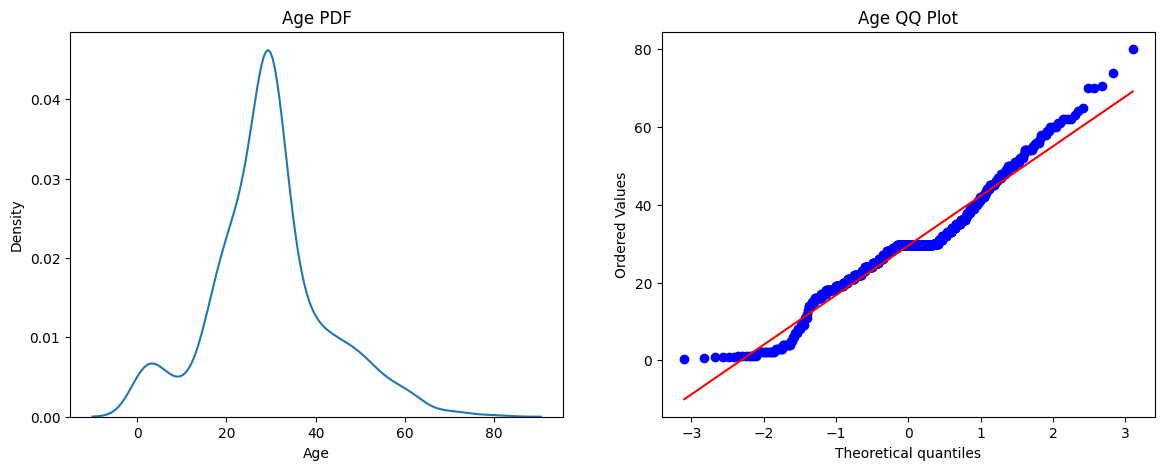

In [31]:
fig,(a1,a2)=plt.subplots(ncols=2,figsize=(14,5))
sns.kdeplot(X_train,x=X_train['Age'],ax=a1)
a1.set_title('Age PDF')
probplot(X_train['Age'],dist='norm',plot=a2)
a2.set_title('Age QQ Plot')

Text(0.5, 1.0, 'Fare QQ Plot')

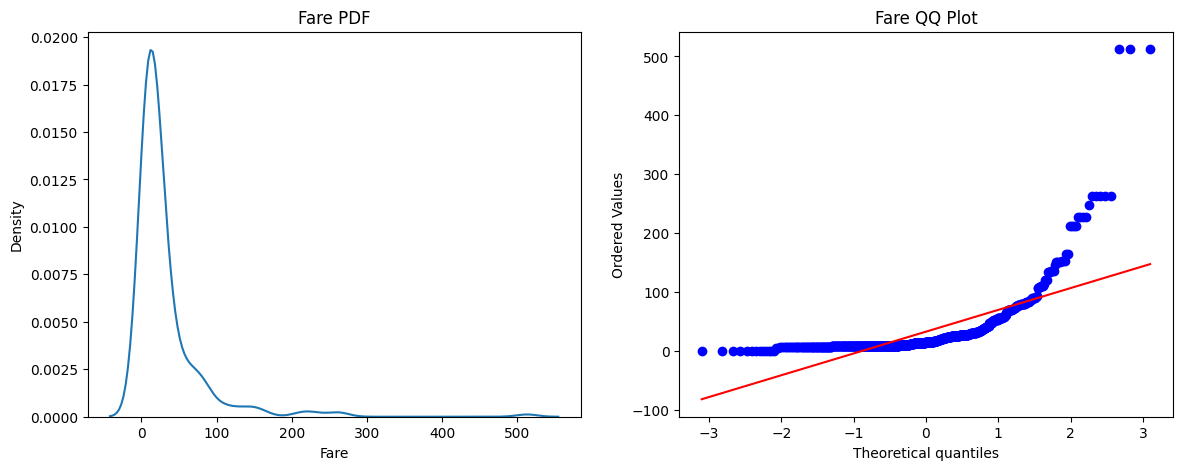

In [32]:
fig,(a1,a2)=plt.subplots(ncols=2,figsize=(14,5))
sns.kdeplot(X_train,x=X_train['Fare'],ax=a1)
a1.set_title('Fare PDF')
probplot(X_train['Fare'],dist='norm',plot=a2)
a2.set_title('Fare QQ Plot')

In [33]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)
Y_pred_1=clf1.predict(X_test)
Y_pred_2=clf2.predict(X_test)

In [34]:
acc1=accuracy_score(y_test,Y_pred_1)
acc2=accuracy_score(y_test,Y_pred_2)
print(acc1,acc2)

0.6480446927374302 0.6759776536312849


In [35]:
trf=FunctionTransformer(func=np.log1p)

In [36]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

In [37]:
clf1.fit(X_train_trf,y_train)
clf2.fit(X_train_trf,y_train)
Y_pred_1=clf1.predict(X_test_trf)
Y_pred_2=clf2.predict(X_test_trf)

In [38]:
acc1=accuracy_score(y_test,Y_pred_1)
acc2=accuracy_score(y_test,Y_pred_2)
print(acc1,acc2)

0.6815642458100558 0.6815642458100558


In [41]:
X_trf=trf.fit_transform(df.drop(columns=['Survived']))
print('LR',np.mean(cross_val_score(clf1,X_trf,df['Survived'],scoring='accuracy',cv=10)))
print('DT',np.mean(cross_val_score(clf2,X_trf,df['Survived'],scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6610861423220975


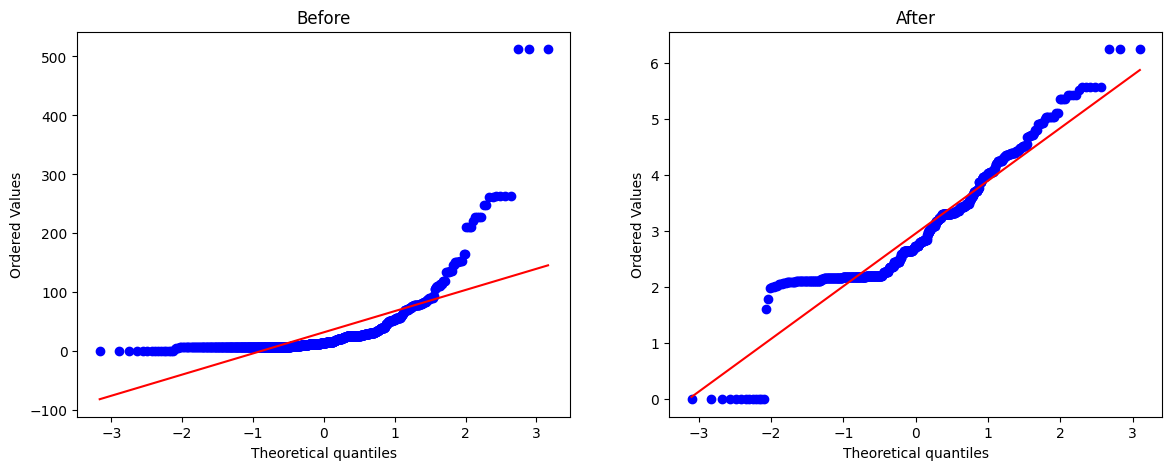

In [45]:
fig,(a1,a2)=plt.subplots(ncols=2,figsize=(14,5))
probplot(df['Fare'],dist='norm',plot=a1)
a1.set_title('Before')
probplot(X_train_trf['Fare'],dist='norm',plot=a2)
a2.set_title('After')
plt.show()

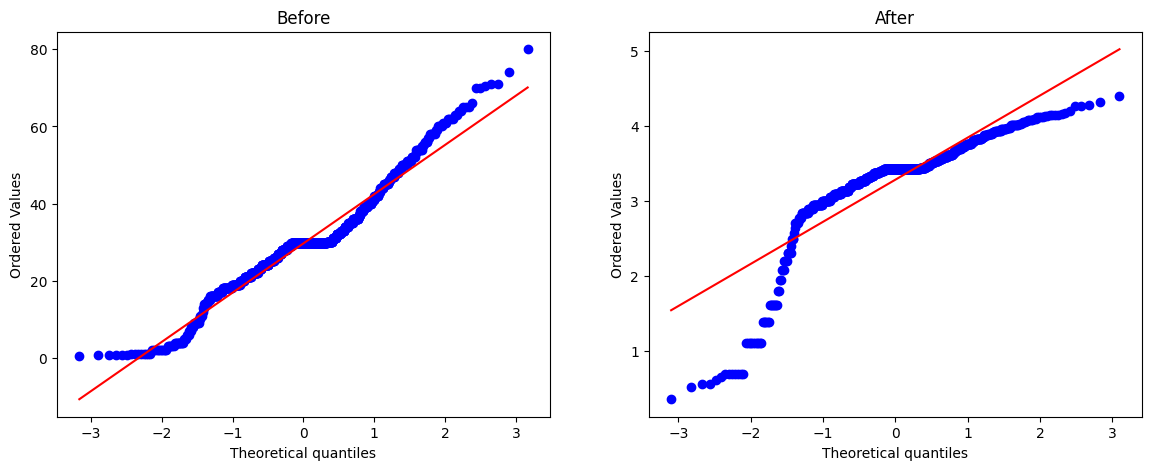

In [46]:
fig,(a1,a2)=plt.subplots(ncols=2,figsize=(14,5))
probplot(df['Age'],dist='norm',plot=a1)
a1.set_title('Before')
probplot(X_train_trf['Age'],dist='norm',plot=a2)
a2.set_title('After')
plt.show()

In [47]:
trf2=ColumnTransformer([('log',FunctionTransformer(func=np.log1p),['Fare'])],remainder='passthrough')

In [48]:
X_train_trf2=trf2.fit_transform(X_train)
X_test_trf2=trf2.transform(X_test)
clf1.fit(X_train_trf2,y_train)
clf2.fit(X_train_trf2,y_train)
Y_pred_1=clf1.predict(X_test_trf2)
Y_pred_2=clf2.predict(X_test_trf2)

In [50]:
acc1=accuracy_score(y_test,Y_pred_1)
acc2=accuracy_score(y_test,Y_pred_2)
print(acc1,acc2)

0.6703910614525139 0.6759776536312849


In [51]:
X_trf2=trf2.fit_transform(df.drop(columns=['Survived']))
print('LR',np.mean(cross_val_score(clf1,X_trf2,df['Survived'],scoring='accuracy',cv=10)))
print('DT',np.mean(cross_val_score(clf2,X_trf2,df['Survived'],scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6565917602996254


In [56]:
def apply_tranform(transform):
  trf=ColumnTransformer([('log',FunctionTransformer(func=transform),['Fare'])],remainder='passthrough')
  X_trans=trf.fit_transform(df.drop(columns=['Survived']))
  print('LR',np.mean(cross_val_score(clf1,X_trans,df['Survived'],scoring='accuracy',cv=10)))
  fig,(a1,a2)=plt.subplots(ncols=2,figsize=(14,5))
  probplot(df.drop(columns=['Survived'])['Fare'],dist='norm',plot=a1)
  a1.set_title('Before')
  probplot(X_trans[:,0],dist='norm',plot=a2)
  a2.set_title('After')
  plt.show()

LR 0.6712609238451936


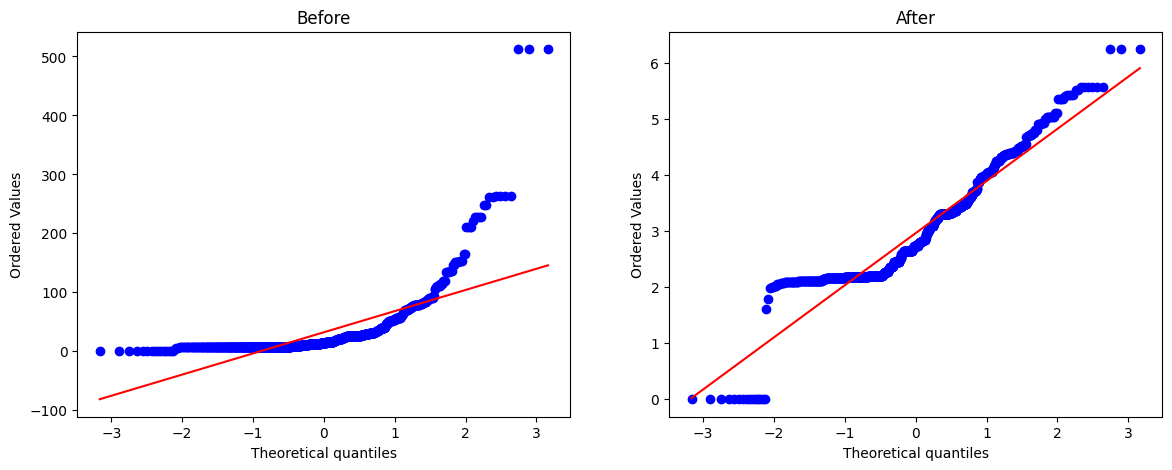

In [67]:
apply_tranform(lambda x:np.log1p(x))